In [11]:
# 10 - Testing
# A dedicated, unbiased evaluation of the winning model architecture on truly unseen data.

# Why this notebook is separate from 07/08: 
# The model saved in best_model.pkl was refit on ALL 186 labeled rows (train+test combined), so it has already "seen" the test set -- fine for making new predictions in 08_Prediction.ipynb, but not valid for an honest test-set evaluation. 
# Here we rebuild the SAME architecture with the SAME tuned hyperparameters, but train it only on X_train and evaluate only on X_test -- data it has never seen -- for a clean read on generalization.

# Covers: confusion matrix on the test set, full classification report,
# ROC curves (one-vs-rest, since this is a 3-class problem), a train-vs-test score comparison, and a learning curve (train score vs cross-validation score as training set size grows) to visualize overfitting directly.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                              f1_score, roc_curve, auc)
import xgboost as xgb

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


In [2]:
# Load the winning architecture + tuned hyperparameters from notebook 07 
bundle = joblib.load('data/processed/models/best_model.pkl')
model_name = bundle['model_name']
best_params = bundle['best_params']
print(f"Testing architecture: {model_name}")
print(f"Tuned hyperparameters: {best_params}")

ml_dir = 'data/processed/ml_ready'
X_train = pd.read_csv(f'{ml_dir}/X_train.csv')
X_test = pd.read_csv(f'{ml_dir}/X_test.csv')
y_train = pd.read_csv(f'{ml_dir}/y_train.csv').iloc[:, 0]
y_test = pd.read_csv(f'{ml_dir}/y_test.csv').iloc[:, 0]
print(f"Train: {X_train.shape} (used to fit) | Test: {X_test.shape} (never seen until now)")


Testing architecture: Random Forest
Tuned hyperparameters: {'n_estimators': 206, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 2}
Train: (139, 26) (used to fit) | Test: (47, 26) (never seen until now)


In [3]:
#  Rebuild the same architecture, train ONLY on X_train 
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

builders = {
    'Logistic Regression': lambda p: LogisticRegression(max_iter=1000, class_weight='balanced', **p),
    'Decision Tree': lambda p: DecisionTreeClassifier(random_state=42, class_weight='balanced', **p),
    'Random Forest': lambda p: RandomForestClassifier(random_state=42, class_weight='balanced', **p),
    'XGBoost': lambda p: xgb.XGBClassifier(eval_metric='mlogloss', random_state=42, **p),
}
test_model = builders[model_name](best_params)

if model_name == 'XGBoost':
    test_model.fit(X_train, y_train_enc)
    pred_train = le.inverse_transform(test_model.predict(X_train))
    pred_test = le.inverse_transform(test_model.predict(X_test))
    proba_test = test_model.predict_proba(X_test)
    classes = le.classes_
else:
    test_model.fit(X_train, y_train)
    pred_train = test_model.predict(X_train)
    pred_test = test_model.predict(X_test)
    proba_test = test_model.predict_proba(X_test)
    classes = test_model.classes_

print(f"Test accuracy (unseen data): {accuracy_score(y_test, pred_test):.3f}")
print(f"Test macro-F1 (unseen data): {f1_score(y_test, pred_test, average='macro', zero_division=0):.3f}")


Test accuracy (unseen data): 0.362
Test macro-F1 (unseen data): 0.332


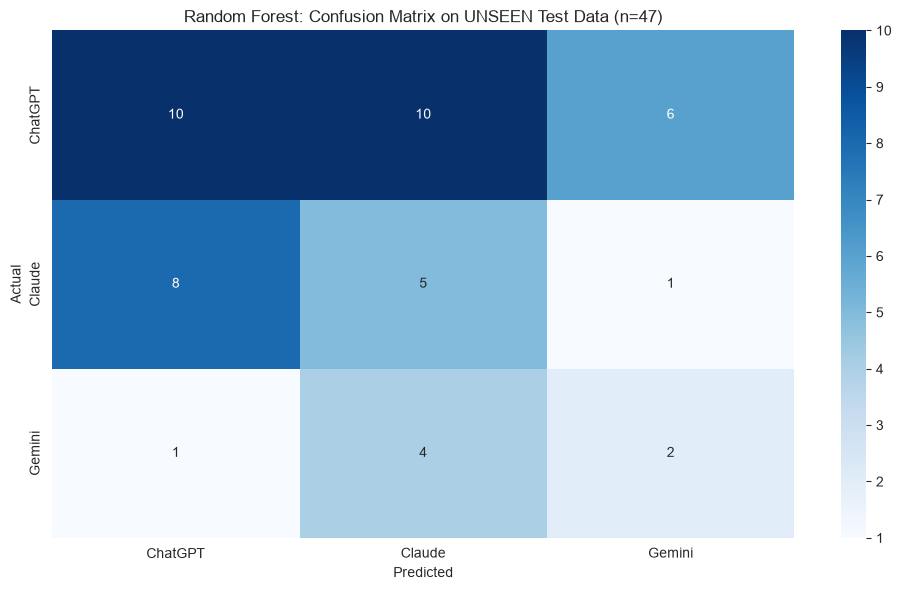

In [5]:
#  Diagram: confusion matrix on the held-out test set 
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, pred_test, labels=labels)
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'{model_name}: Confusion Matrix on UNSEEN Test Data (n={len(y_test)})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


In [6]:
# Full classification report on the test set 
print(classification_report(y_test, pred_test, zero_division=0))


              precision    recall  f1-score   support

     ChatGPT       0.53      0.38      0.44        26
      Claude       0.26      0.36      0.30        14
      Gemini       0.22      0.29      0.25         7

    accuracy                           0.36        47
   macro avg       0.34      0.34      0.33        47
weighted avg       0.40      0.36      0.37        47



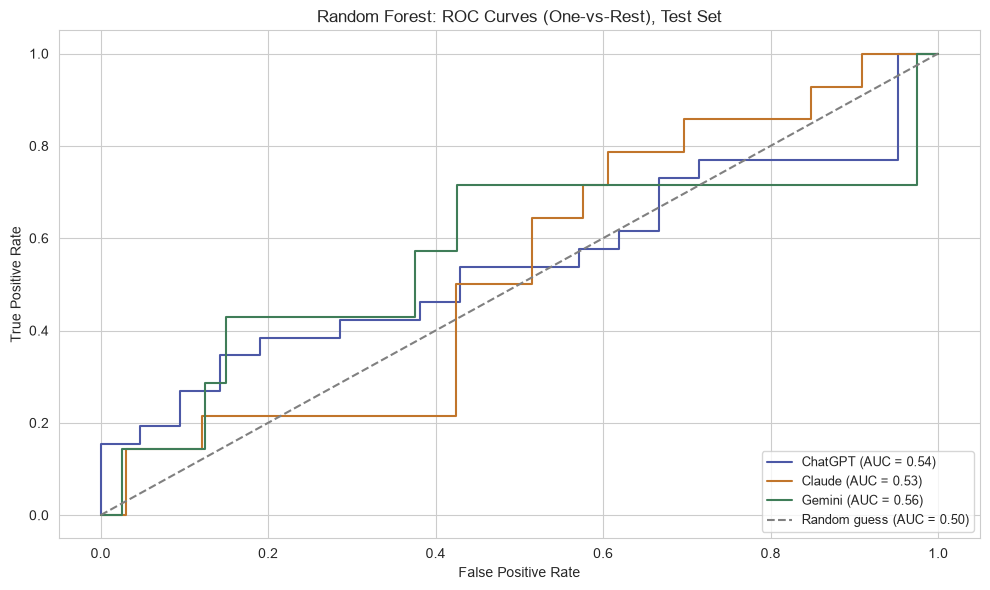

In [7]:
#  Diagram: ROC curves, one-vs-rest (multiclass)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(10, 6))
colors = ['#4C58A6', '#C1752B', '#3F7D58', '#AF4A3B']
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba_test[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.2f})', color=colors[i % len(colors)])

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'{model_name}: ROC Curves (One-vs-Rest), Test Set')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

# Note: AUC close to 0.5 for any class means the model does little better than
# chance at separating that class from the rest -- worth reporting honestly
# alongside the macro-F1, especially for the smallest class (Gemini).


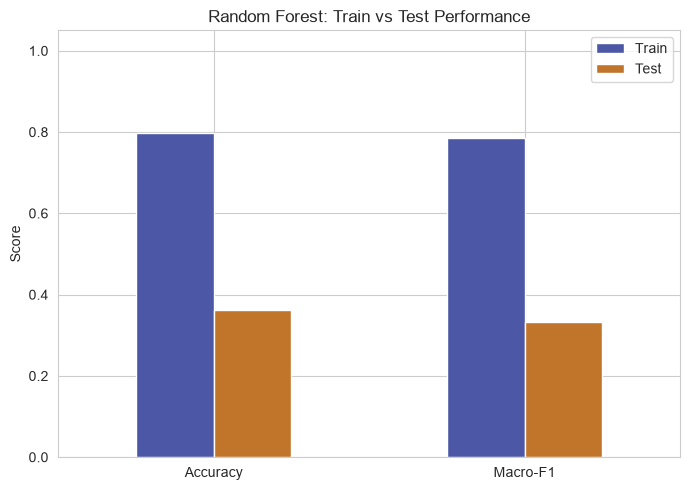

,Train,Test
Accuracy,0.799,0.362
Macro-F1,0.786,0.332


In [8]:
# Diagram: train vs test score comparison (single-split overfitting check) 
train_acc = accuracy_score(y_train, pred_train)
test_acc = accuracy_score(y_test, pred_test)
train_f1 = f1_score(y_train, pred_train, average='macro', zero_division=0)
test_f1 = f1_score(y_test, pred_test, average='macro', zero_division=0)

comparison = pd.DataFrame({
    'Train': [train_acc, train_f1],
    'Test': [test_acc, test_f1],
}, index=['Accuracy', 'Macro-F1'])

comparison.plot(kind='bar', figsize=(7, 5), color=['#4C58A6', '#C1752B'])
plt.title(f'{model_name}: Train vs Test Performance')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()
comparison.round(3)


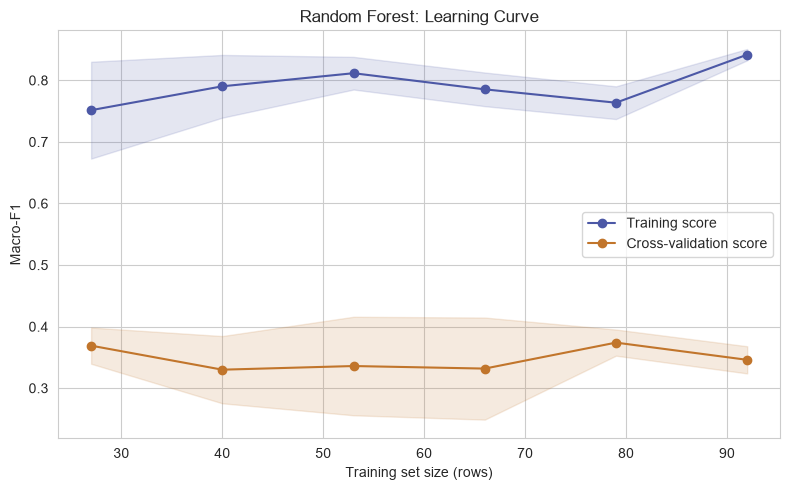

In [9]:
#  Diagram: learning curve - train score vs cross-validation score by training size 
# Shows whether the model would likely improve with more data (if the CV line
# is still rising) or has plateaued (flat CV line despite more training rows).
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
lc_model = builders[model_name](best_params)
lc_y = y_train_enc if model_name == 'XGBoost' else y_train

train_sizes, train_scores, cv_scores = learning_curve(
    lc_model, X_train, lc_y, cv=cv, scoring='f1_macro',
    train_sizes=np.linspace(0.3, 1.0, 6), n_jobs=-1
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#4C58A6', label='Training score')
plt.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                  train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color='#4C58A6')
plt.plot(train_sizes, cv_scores.mean(axis=1), 'o-', color='#C1752B', label='Cross-validation score')
plt.fill_between(train_sizes, cv_scores.mean(axis=1) - cv_scores.std(axis=1),
                  cv_scores.mean(axis=1) + cv_scores.std(axis=1), alpha=0.15, color='#C1752B')
plt.xlabel('Training set size (rows)')
plt.ylabel('Macro-F1')
plt.title(f'{model_name}: Learning Curve')
plt.legend(loc='center right')
plt.tight_layout()
plt.show()

# A wide, persistent gap between the two lines (as seen here) is the signature of overfitting on a small dataset: the model memorizes the
# training rows (near-perfect training score) but that doesn't transfer to unseen rows. 
# The cross-validation line staying roughly flat as training size grows suggests more respondents , not just more tuning is the more effective lever for improving this model.


In [10]:
# Save the test evaluation report 
import os
report_dict = classification_report(y_test, pred_test, zero_division=0, output_dict=True)
report_df = pd.DataFrame(report_dict).T.round(3)
os.makedirs('data/processed', exist_ok=True)
report_df.to_csv('data/processed/Testing_Report.csv')
print("Saved: data/processed/Testing_Report.csv")
report_df


Saved: data/processed/Testing_Report.csv


,precision,recall,f1-score,support
ChatGPT,0.526,0.385,0.444,26.000
Claude,0.263,0.357,0.303,14.000
Gemini,0.222,0.286,0.250,7.000
accuracy,0.362,0.362,0.362,0.362
macro avg,0.337,0.342,0.332,47.000
weighted avg,0.403,0.362,0.373,47.000
